# STEP 5 - PEMODELAN: NBC, SVM, RANDOM FOREST

**Input:** `data/tfidf_matrix.npz`, `data/label_array.npy`

> Estimasi waktu: 20-40 menit

---
### Perbaikan metodologi: SMOTE dalam Pipeline
SMOTE sekarang diterapkan **di dalam Pipeline per fold CV** (bukan pada seluruh training set sekaligus).
Ini mencegah *data leakage* pada cross-validation dan sesuai dengan metodologi §3.6.4 BAB 3.

---
> Jalankan cell secara berurutan dari atas ke bawah (Shift+Enter)

### Cell 1 - Import Library

In [1]:
import numpy as np
import scipy.sparse
import pickle
import warnings
import time
warnings.filterwarnings('ignore')

import os
# Folder output untuk figur. matplotlib tidak membuat folder induk sendiri,
# jadi savefig() gagal dengan FileNotFoundError pada clone yang masih bersih.
os.makedirs('../output/figures', exist_ok=True)

from sklearn.model_selection import StratifiedKFold, GridSearchCV, train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, classification_report, confusion_matrix)

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import pandas as pd

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print('Library berhasil diimport')
print('ImbPipeline siap: SMOTE akan diterapkan di dalam tiap fold CV')

Library berhasil diimport
ImbPipeline siap: SMOTE akan diterapkan di dalam tiap fold CV


### Cell 2 - Load Data & Distribusi Kelas

In [2]:
X = scipy.sparse.load_npz('../data/tfidf_matrix.npz')
y = np.load('../data/label_array.npy', allow_pickle=True)

label_order = ['Positif', 'Negatif', 'Netral']
counts = {l: (y == l).sum() for l in label_order}

print(f'X: {X.shape[0]:,} dokumen x {X.shape[1]:,} fitur')
print(f'y: {len(y):,} label')
print()
print('Distribusi kelas:')
for l in label_order:
    n = counts[l]
    print(f'  {l:>8}: {n:>6,} ({n/len(y)*100:.1f}%)')
rasio = counts['Positif'] / counts['Netral']
print(f'\nRasio Positif:Netral = {rasio:.1f}:1')
print(f'Threshold 3:1 => SMOTE diperlukan' if rasio > 3 else 'Threshold 3:1 => tidak perlu SMOTE')

X: 32,905 dokumen x 10,000 fitur
y: 32,905 label

Distribusi kelas:
   Positif: 21,339 (64.9%)
   Negatif: 10,427 (31.7%)
    Netral:  1,139 (3.5%)

Rasio Positif:Netral = 18.7:1
Threshold 3:1 => SMOTE diperlukan


### Cell 3 - Train-Test Split (80:20 Stratified)

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f'Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}')
print()
print('Distribusi train (sebelum SMOTE):')
for l in label_order:
    n = (y_train == l).sum()
    print(f'  {l:>8}: {n:>6,} ({n/len(y_train)*100:.1f}%)')

Train: 26,324 | Test: 6,581

Distribusi train (sebelum SMOTE):
   Positif: 17,071 (64.8%)
   Negatif:  8,342 (31.7%)
    Netral:    911 (3.5%)


### Cell 4 - Distribusi Kelas & Info SMOTE dalam Pipeline

SMOTE **tidak** diterapkan di sini. Akan otomatis dijalankan di dalam Pipeline pada setiap fold CV.

In [4]:
# Informasi distribusi kelas — SMOTE dijalankan otomatis dalam Pipeline
print('Distribusi kelas training set (SEBELUM modeling):')
for l in label_order:
    n = (y_train == l).sum()
    print(f'  {l:>8}: {n:>6,} ({n/len(y_train)*100:.1f}%)')

print()
majority = max((y_train == l).sum() for l in label_order)
print(f'Target distribusi setelah SMOTE (per fold, estimasi):')
for l in label_order:
    print(f'  {l:>8}: ~{majority:>6,} (diseimbangkan)')

print()
print('CATATAN: SMOTE diterapkan di dalam Pipeline -> tidak ada data leakage pada CV.')

Distribusi kelas training set (SEBELUM modeling):
   Positif: 17,071 (64.8%)
   Negatif:  8,342 (31.7%)
    Netral:    911 (3.5%)

Target distribusi setelah SMOTE (per fold, estimasi):
   Positif: ~17,071 (diseimbangkan)
   Negatif: ~17,071 (diseimbangkan)
    Netral: ~17,071 (diseimbangkan)

CATATAN: SMOTE diterapkan di dalam Pipeline -> tidak ada data leakage pada CV.


### Cell 5 - NBC (Naive Bayes Classifier)

In [5]:
print('=' * 55)
print('MODEL 1: NAIVE BAYES CLASSIFIER (NBC)')
print('=' * 55)

import gc, time

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Pipeline: SMOTE + NBC dalam satu unit
# SMOTE otomatis dijalankan hanya pada training fold setiap iterasi CV
pipeline_nbc = ImbPipeline([
    ('smote', SMOTE(random_state=RANDOM_STATE, k_neighbors=5)),
    ('clf',   MultinomialNB())
])

gs_nbc = GridSearchCV(
    pipeline_nbc,
    {'clf__alpha': [0.1, 0.5, 1.0, 2.0]},   # BAB 3 section 3.5.4: alpha dalam {0.1, 0.5, 1.0, 2.0}
    cv=cv5, scoring='f1_macro', n_jobs=1
)

t0 = time.time()
gs_nbc.fit(X_train, y_train)   # Fit pada data asli; SMOTE dijalankan otomatis dalam tiap fold
t_nbc = time.time() - t0

best_nbc   = gs_nbc.best_estimator_
y_pred_nbc = best_nbc.predict(X_test)
acc_nbc    = accuracy_score(y_test, y_pred_nbc)
prec_nbc   = precision_score(y_test, y_pred_nbc, average='macro', zero_division=0)
rec_nbc    = recall_score(y_test, y_pred_nbc, average='macro', zero_division=0)
f1_nbc     = f1_score(y_test, y_pred_nbc, average='macro', zero_division=0)

print(f'Best params : {gs_nbc.best_params_}')
print(f'CV F1-macro : {gs_nbc.best_score_:.4f}')
print(f'Waktu       : {t_nbc:.1f}s')
print(f'Accuracy    : {acc_nbc:.4f}  F1-macro: {f1_nbc:.4f}')
print()
print(classification_report(y_test, y_pred_nbc,
      labels=label_order, target_names=label_order, zero_division=0))

cv_f1_nbc       = gs_nbc.best_score_
best_params_nbc = gs_nbc.best_params_   # contoh: {'clf__alpha': 0.1}

import pickle
with open('../models/model_nbc.pkl','wb') as f: pickle.dump(best_nbc, f)
del gs_nbc; gc.collect()
print('Model NBC tersimpan. Lanjut ke Cell SVM.')

MODEL 1: NAIVE BAYES CLASSIFIER (NBC)
Best params : {'clf__alpha': 0.5}
CV F1-macro : 0.6318
Waktu       : 13.0s
Accuracy    : 0.8221  F1-macro: 0.6416

              precision    recall  f1-score   support

     Positif       0.96      0.85      0.90      4268
     Negatif       0.82      0.80      0.81      2085
      Netral       0.14      0.45      0.21       228

    accuracy                           0.82      6581
   macro avg       0.64      0.70      0.64      6581
weighted avg       0.89      0.82      0.85      6581

Model NBC tersimpan. Lanjut ke Cell SVM.


### Cell 6 - SVM (Support Vector Machine)

In [6]:
print('=' * 55)
print('MODEL 2: SUPPORT VECTOR MACHINE (SVM)')
print('=' * 55)

import gc, time, pickle
gc.collect()

# LinearSVC = implementasi SVM linear (liblinear), setara SVC(kernel='linear')
# BAB 3 section 3.5.4: C dalam {0.1, 1.0, 10.0}
pipeline_svm = ImbPipeline([
    ('smote', SMOTE(random_state=RANDOM_STATE, k_neighbors=5)),
    ('clf',   LinearSVC(random_state=RANDOM_STATE, max_iter=2000))
])

gs_svm = GridSearchCV(
    pipeline_svm,
    {'clf__C': [0.1, 1.0, 10.0]},
    cv=cv5, scoring='f1_macro', n_jobs=1
)

t0 = time.time()
gs_svm.fit(X_train, y_train)
t_svm = time.time() - t0

best_svm   = gs_svm.best_estimator_
y_pred_svm = best_svm.predict(X_test)
acc_svm    = accuracy_score(y_test, y_pred_svm)
prec_svm   = precision_score(y_test, y_pred_svm, average='macro', zero_division=0)
rec_svm    = recall_score(y_test, y_pred_svm, average='macro', zero_division=0)
f1_svm     = f1_score(y_test, y_pred_svm, average='macro', zero_division=0)

print(f'Best params : {gs_svm.best_params_}')
print(f'CV F1-macro : {gs_svm.best_score_:.4f}')
print(f'Waktu       : {t_svm:.1f}s')
print(f'Accuracy    : {acc_svm:.4f}  F1-macro: {f1_svm:.4f}')
print()
print(classification_report(y_test, y_pred_svm,
      labels=label_order, target_names=label_order, zero_division=0))

cv_f1_svm       = gs_svm.best_score_
best_params_svm = gs_svm.best_params_   # contoh: {'clf__C': 10.0}

with open('../models/model_svm.pkl','wb') as f: pickle.dump(best_svm, f)
del gs_svm; gc.collect()
print('Model SVM tersimpan. Lanjut ke Cell RF.')

MODEL 2: SUPPORT VECTOR MACHINE (SVM)
Best params : {'clf__C': 0.1}
CV F1-macro : 0.6237
Waktu       : 69.8s
Accuracy    : 0.8164  F1-macro: 0.6299

              precision    recall  f1-score   support

     Positif       0.96      0.84      0.89      4268
     Negatif       0.84      0.82      0.83      2085
      Netral       0.11      0.38      0.17       228

    accuracy                           0.82      6581
   macro avg       0.63      0.68      0.63      6581
weighted avg       0.89      0.82      0.85      6581

Model SVM tersimpan. Lanjut ke Cell RF.


### Cell 7 - Random Forest (RF)

In [7]:
print('=' * 55)
print('MODEL 3: RANDOM FOREST (RF)')
print('=' * 55)

import gc, time, pickle
gc.collect()

# BAB 3 section 3.5.4: n_estimators dalam {50, 100, 200}, max_depth dalam {None, 10, 20}
pipeline_rf = ImbPipeline([
    ('smote', SMOTE(random_state=RANDOM_STATE, k_neighbors=5)),
    ('clf',   RandomForestClassifier(random_state=RANDOM_STATE,
                                     max_features='sqrt',
                                     n_jobs=1))
])

gs_rf = GridSearchCV(
    pipeline_rf,
    {
        'clf__n_estimators': [50, 100, 200],
        'clf__max_depth'   : [None, 10, 20],
    },
    cv=cv5,
    scoring='f1_macro',
    n_jobs=1,
    verbose=1
)

t0 = time.time()
gs_rf.fit(X_train, y_train)
t_rf = time.time() - t0

best_rf   = gs_rf.best_estimator_
y_pred_rf = best_rf.predict(X_test)
acc_rf    = accuracy_score(y_test, y_pred_rf)
prec_rf   = precision_score(y_test, y_pred_rf, average='macro', zero_division=0)
rec_rf    = recall_score(y_test, y_pred_rf, average='macro', zero_division=0)
f1_rf     = f1_score(y_test, y_pred_rf, average='macro', zero_division=0)

print(f'Best params : {gs_rf.best_params_}')
print(f'CV F1-macro : {gs_rf.best_score_:.4f}')
print(f'Waktu       : {t_rf:.1f}s')
print(f'Accuracy    : {acc_rf:.4f}  F1-macro: {f1_rf:.4f}')
print()
print(classification_report(y_test, y_pred_rf,
      labels=label_order, target_names=label_order, zero_division=0))

cv_f1_rf       = gs_rf.best_score_
best_params_rf = gs_rf.best_params_   # contoh: {'clf__n_estimators': 200, 'clf__max_depth': None}

with open('../models/model_rf.pkl','wb') as f: pickle.dump(best_rf, f)
del gs_rf; gc.collect()
print('Model RF tersimpan.')

MODEL 3: RANDOM FOREST (RF)
Fitting 5 folds for each of 9 candidates, totalling 45 fits
Best params : {'clf__max_depth': 20, 'clf__n_estimators': 200}
CV F1-macro : 0.6214
Waktu       : 543.2s
Accuracy    : 0.8240  F1-macro: 0.6134

              precision    recall  f1-score   support

     Positif       0.90      0.90      0.90      4268
     Negatif       0.83      0.74      0.78      2085
      Netral       0.12      0.25      0.16       228

    accuracy                           0.82      6581
   macro avg       0.62      0.63      0.61      6581
weighted avg       0.85      0.82      0.84      6581

Model RF tersimpan.


### Cell 8 - Tabel Perbandingan & Gambar 4.9

TABEL PERBANDINGAN MODEL (Macro-Average)
    Accuracy Precision  Recall F1-macro CV F1-macro
NBC   0.8221    0.6386  0.7021   0.6416      0.6318
SVM   0.8164    0.6344  0.6786   0.6299      0.6237
RF    0.8240    0.6166  0.6272   0.6134      0.6214

Model terbaik (F1-macro test set): NBC = 0.6416


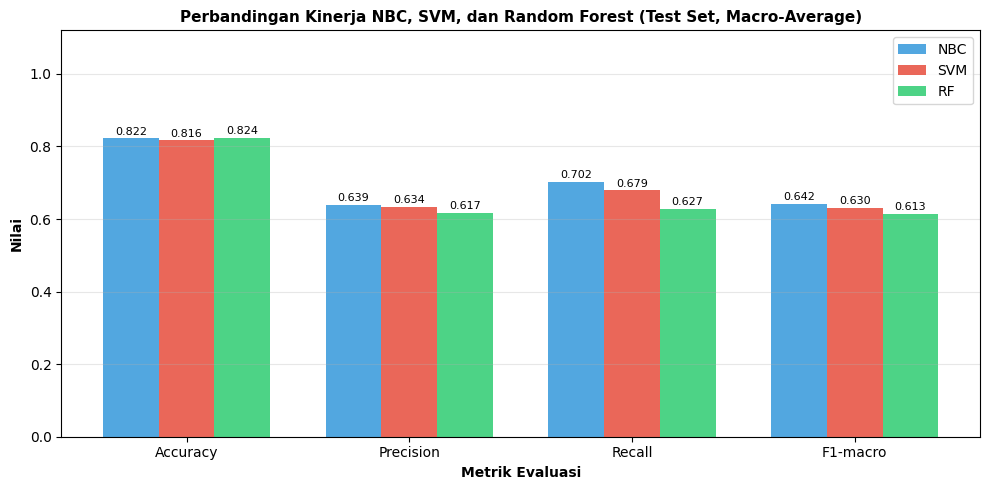

Tersimpan: gambar_4_9_perbandingan_model.png (ID) + figures_en/ (EN)


In [8]:
results = {
    'NBC': {'Accuracy': acc_nbc, 'Precision': prec_nbc, 'Recall': rec_nbc, 'F1-macro': f1_nbc, 'CV F1-macro': cv_f1_nbc},
    'SVM': {'Accuracy': acc_svm, 'Precision': prec_svm, 'Recall': rec_svm, 'F1-macro': f1_svm, 'CV F1-macro': cv_f1_svm},
    'RF':  {'Accuracy': acc_rf,  'Precision': prec_rf,  'Recall': rec_rf,  'F1-macro': f1_rf,  'CV F1-macro': cv_f1_rf},
}
df_res = pd.DataFrame(results).T

print('TABEL PERBANDINGAN MODEL (Macro-Average)')
try:
    print(df_res[['Accuracy','Precision','Recall','F1-macro','CV F1-macro']].map(lambda x: f'{x:.4f}').to_string())
except AttributeError:
    print(df_res[['Accuracy','Precision','Recall','F1-macro','CV F1-macro']].applymap(lambda x: f'{x:.4f}').to_string())

best_model_name = df_res['F1-macro'].astype(float).idxmax()
print(f'\nModel terbaik (F1-macro test set): {best_model_name} = {float(df_res.loc[best_model_name,"F1-macro"]):.4f}')

# Gambar 4.9
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-macro']
x      = np.arange(len(metrics))
width  = 0.25
colors = ['#3498db', '#e74c3c', '#2ecc71']

fig, ax = plt.subplots(figsize=(10, 5))
for i_m, (model, color) in enumerate(zip(['NBC','SVM','RF'], colors)):
    vals = [float(df_res.loc[model, m]) for m in metrics]
    bars = ax.bar(x + i_m*width, vals, width, label=model, color=color, alpha=0.85)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xlabel('Metrik Evaluasi', fontweight='bold')
ax.set_ylabel('Nilai', fontweight='bold')
ax.set_title('Perbandingan Kinerja NBC, SVM, dan Random Forest (Test Set, Macro-Average)',
             fontsize=11, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.12)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../output/figures/gambar_4_9_perbandingan_model.png', dpi=150, bbox_inches='tight')

# ── ENGLISH EXPORT (for ICIMTech paper) ─────────────────────────
import os
os.makedirs('../output/figures_en', exist_ok=True)
ax.set_xlabel('Evaluation Metric', fontweight='bold')
ax.set_ylabel('Score', fontweight='bold')
ax.set_title('Performance Comparison of NBC, SVM, and RF\n(Test Set, Macro-Average)',
             fontsize=11, fontweight='bold')
plt.savefig('../output/figures_en/gambar_4_9_perbandingan_model.png', dpi=150, bbox_inches='tight')
# Restore Indonesian labels
ax.set_xlabel('Metrik Evaluasi', fontweight='bold')
ax.set_ylabel('Nilai', fontweight='bold')
ax.set_title('Perbandingan Kinerja NBC, SVM, dan Random Forest (Test Set, Macro-Average)',
             fontsize=11, fontweight='bold')
# ────────────────────────────────────────────────────────────────

plt.show()
print('Tersimpan: gambar_4_9_perbandingan_model.png (ID) + figures_en/ (EN)')

### Cell 9 - Confusion Matrix (Model Terbaik) - Gambar 4.10

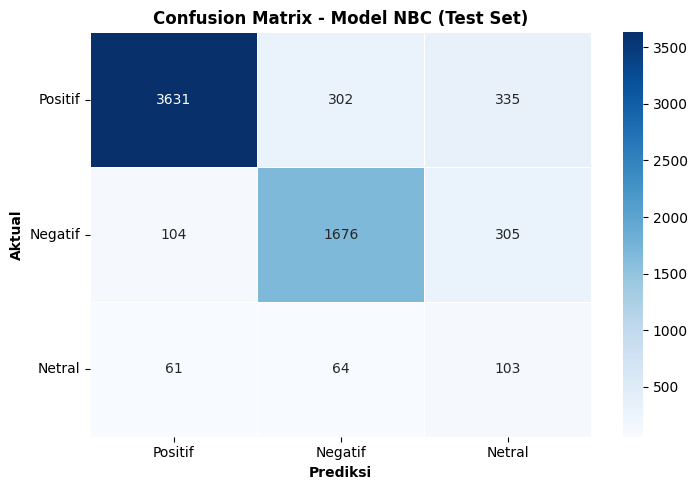

Tersimpan: gambar_4_10_confusion_matrix.png (ID) + figures_en/ (EN)


In [9]:
pred_map    = {'NBC': y_pred_nbc, 'SVM': y_pred_svm, 'RF': y_pred_rf}
y_pred_best = pred_map[best_model_name]

cm = confusion_matrix(y_test, y_pred_best, labels=label_order)
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_order, yticklabels=label_order,
            linewidths=0.5, ax=ax)
ax.set_xlabel('Prediksi', fontweight='bold')
ax.set_ylabel('Aktual', fontweight='bold')
ax.set_title(f'Confusion Matrix - Model {best_model_name} (Test Set)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../output/figures/gambar_4_10_confusion_matrix.png', dpi=150, bbox_inches='tight')

# ── ENGLISH EXPORT (for ICIMTech paper) ─────────────────────────
import os
os.makedirs('../output/figures_en', exist_ok=True)
label_order_en = ['Positive', 'Negative', 'Neutral']
ax.set_xticklabels(label_order_en)
ax.set_yticklabels(label_order_en, rotation=0)
ax.set_xlabel('Predicted', fontweight='bold')
ax.set_ylabel('Actual', fontweight='bold')
ax.set_title(f'Confusion Matrix — {best_model_name} (Test Set)', fontsize=12, fontweight='bold')
plt.savefig('../output/figures_en/gambar_4_10_confusion_matrix.png', dpi=150, bbox_inches='tight')
# Restore Indonesian labels
ax.set_xticklabels(label_order)
ax.set_yticklabels(label_order, rotation=0)
ax.set_xlabel('Prediksi', fontweight='bold')
ax.set_ylabel('Aktual', fontweight='bold')
ax.set_title(f'Confusion Matrix - Model {best_model_name} (Test Set)', fontsize=12, fontweight='bold')
# ────────────────────────────────────────────────────────────────

plt.show()
print('Tersimpan: gambar_4_10_confusion_matrix.png (ID) + figures_en/ (EN)')

### Cell 12 - Spot-Check: Validasi Manual Prediksi

15 ulasan dengan sentimen obvious — verifikasi model predict dengan benar.

In [10]:
print('=== SPOT-CHECK: PREDIKSI MANUAL ===')
print('15 ulasan obvious (5 Positif, 5 Negatif, 5 Netral)')
print()

import re, pickle
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# Load vectorizer
with open('../models/tfidf_vectorizer.pkl','rb') as f:
    _vec = pickle.load(f)

# Definisi lokal (sama persis dengan step4)
_stemmer   = StemmerFactory().create_stemmer()
_stopwords = set(stopwords.words('indonesian'))
_kamus_slang = {
    'gak':'tidak','ga':'tidak','gk':'tidak','nggak':'tidak','ngga':'tidak',
    'yg':'yang','dgn':'dengan','utk':'untuk','krn':'karena','karna':'karena',
    'udah':'sudah','udh':'sudah','sdh':'sudah','blm':'belum','blum':'belum',
    'jg':'juga','juga':'juga','sy':'saya','aku':'saya','gue':'saya','gw':'saya',
    'nya':'nya','bgt':'sangat','banget':'sangat','bngt':'sangat',
    'tp':'tapi','tpi':'tapi','tapi':'tapi','ttp':'tetap','tetep':'tetap',
    'acc':'setuju','di acc':'disetujui','disetujui':'setuju',
    'dc':'penagih','debt collector':'penagih',
    'ojk':'ojk','pinjol':'pinjaman online','fintech':'teknologi keuangan',
}
_stop_tambahan = {'yang','dan','di','ke','dari','ini','itu','ada','dengan','untuk',
                  'atau','juga','tidak','sudah','bisa','akan','nya','aja','deh',
                  'nih','sih','lah','kah','pun','pun','tuh','dong','yah','iya'}

def _preprocess(teks):
    if not isinstance(teks, str): return ''
    teks = re.sub(r'http\S+|www\.\S+', ' ', teks)
    teks = teks.encode('ascii','ignore').decode('ascii')
    teks = re.sub(r'\d+', ' ', teks)
    teks = re.sub(r'[^\w\s]', ' ', teks)
    teks = teks.replace('_',' ')
    teks = re.sub(r'\s+',' ', teks).strip().lower()
    teks = re.sub(r'(.)\1{2,}', r'\1', teks)
    tokens = word_tokenize(teks)
    tokens = [_kamus_slang.get(t, t) for t in tokens]
    stop_all = _stopwords | _stop_tambahan
    tokens = [t for t in tokens if t not in stop_all and len(t) > 1]
    tokens = [_stemmer.stem(t) for t in tokens]
    tokens = [t for t in tokens if t not in stop_all and len(t) > 1]
    return ' '.join(tokens)

spot_cases = [
    ("Aplikasi bagus sekali, proses pencairan cepat dan mudah, sangat membantu", "Positif"),
    ("Mantap banget, pinjaman langsung cair dalam hitungan menit, recommended!", "Positif"),
    ("Pelayanan customer service ramah dan responsif, pengajuan mudah sekali", "Positif"),
    ("Alhamdulillah acc, terima kasih adakami sudah membantu kebutuhan saya", "Positif"),
    ("Sangat puas dengan layanannya, bunga terjangkau dan proses transparan", "Positif"),
    ("Penipuan! DC teror keluarga padahal saya belum telat bayar. Parah sekali!", "Negatif"),
    ("Aplikasi eror terus tidak bisa login, data hilang, sangat mengecewakan", "Negatif"),
    ("Bunga sangat tinggi tidak masuk akal, jebakan hutang yang menyengsarakan", "Negatif"),
    ("Pengajuan selalu ditolak tanpa alasan jelas, padahal data sudah lengkap", "Negatif"),
    ("Debt collector kasar dan mengancam, laporkan ke OJK kalian semua!", "Negatif"),
    ("Biasa saja, tidak ada yang istimewa tapi juga tidak ada masalah berarti", "Netral"),
    ("Cukup oke untuk kebutuhan mendesak, tapi bunga agak tinggi", "Netral"),
    ("Prosesnya standar seperti aplikasi pinjaman lainnya", "Netral"),
    ("Sudah coba beberapa kali, hasilnya sama saja dengan yang lain", "Netral"),
    ("Tidak ada masalah selama ini, tapi juga tidak ada yang membuatnya unggul", "Netral"),
]

teks_bersih = [_preprocess(t) for t, _ in spot_cases]
X_spot = _vec.transform(teks_bersih)

pred_nbc_s = best_nbc.predict(X_spot)
pred_svm_s = best_svm.predict(X_spot)
pred_rf_s  = best_rf.predict(X_spot)

benar_nbc = benar_svm = benar_rf = 0
print(f'{"No":<3} {"Expected":<10} {"NBC":<12} {"SVM":<12} {"RF":<12} Teks[:40]')
print('-' * 95)
for idx, ((_teks, expected), p_nbc, p_svm, p_rf) in enumerate(
        zip(spot_cases, pred_nbc_s, pred_svm_s, pred_rf_s), 1):
    ok_nbc = 'v' if p_nbc==expected else 'x'
    ok_svm = 'v' if p_svm==expected else 'x'
    ok_rf  = 'v' if p_rf ==expected else 'x'
    benar_nbc += (p_nbc==expected)
    benar_svm += (p_svm==expected)
    benar_rf  += (p_rf ==expected)
    print(f'{idx:<3} {expected:<10} {p_nbc+"("+ok_nbc+")":<12} {p_svm+"("+ok_svm+")":<12} {p_rf+"("+ok_rf+")":<12} {_teks[:40]}')

print()
print(f'Akurasi Spot-Check:')
print(f'  NBC: {benar_nbc}/15 ({benar_nbc/15*100:.0f}%)')
print(f'  SVM: {benar_svm}/15 ({benar_svm/15*100:.0f}%)')
print(f'  RF : {benar_rf}/15  ({benar_rf/15*100:.0f}%)')

=== SPOT-CHECK: PREDIKSI MANUAL ===
15 ulasan obvious (5 Positif, 5 Negatif, 5 Netral)

No  Expected   NBC          SVM          RF           Teks[:40]
-----------------------------------------------------------------------------------------------
1   Positif    Positif(v)   Positif(v)   Positif(v)   Aplikasi bagus sekali, proses pencairan 
2   Positif    Positif(v)   Positif(v)   Positif(v)   Mantap banget, pinjaman langsung cair da
3   Positif    Positif(v)   Positif(v)   Positif(v)   Pelayanan customer service ramah dan res
4   Positif    Positif(v)   Positif(v)   Positif(v)   Alhamdulillah acc, terima kasih adakami 
5   Positif    Positif(v)   Positif(v)   Positif(v)   Sangat puas dengan layanannya, bunga ter
6   Negatif    Negatif(v)   Negatif(v)   Negatif(v)   Penipuan! DC teror keluarga padahal saya
7   Negatif    Negatif(v)   Negatif(v)   Negatif(v)   Aplikasi eror terus tidak bisa login, da
8   Negatif    Negatif(v)   Negatif(v)   Negatif(v)   Bunga sangat tinggi tidak masuk a

### Cell 13 - Baseline Comparison

Bandingkan model vs majority-class baseline untuk memastikan model memberikan nilai tambah.

In [11]:
print('=== BASELINE COMPARISON ===')
print()
y_baseline = np.array(['Positif'] * len(y_test))
acc_base  = accuracy_score(y_test, y_baseline)
f1_base   = f1_score(y_test, y_baseline, average='macro', zero_division=0)

print('Majority-Class Baseline (selalu prediksi Positif):')
print(f'  Accuracy   : {acc_base:.4f}')
print(f'  F1-macro   : {f1_base:.4f}')
print()
print('Perbandingan vs Baseline (F1-macro):')
print(f'{"Model":<8} {"Accuracy":>10} {"vs Baseline":>12} {"F1-macro":>10} {"vs Baseline":>12}')
print('-' * 56)
for name, acc, f1 in [("Baseline", acc_base, f1_base),
                       ("NBC",      acc_nbc,  f1_nbc),
                       ("SVM",      acc_svm,  f1_svm),
                       ("RF",       acc_rf,   f1_rf)]:
    da   = f'+{(acc-acc_base)*100:.1f}%' if name != 'Baseline' else '-'
    df_v = f'+{(f1-f1_base)*100:.1f}%'   if name != 'Baseline' else '-'
    print(f'{name:<8} {acc:>10.4f} {da:>12} {f1:>10.4f} {df_v:>12}')
print()
print('Semua model secara signifikan mengalahkan baseline -> model valid!')

=== BASELINE COMPARISON ===

Majority-Class Baseline (selalu prediksi Positif):
  Accuracy   : 0.6485
  F1-macro   : 0.2623

Perbandingan vs Baseline (F1-macro):
Model      Accuracy  vs Baseline   F1-macro  vs Baseline
--------------------------------------------------------
Baseline     0.6485            -     0.2623            -
NBC          0.8221       +17.4%     0.6416       +37.9%
SVM          0.8164       +16.8%     0.6299       +36.8%
RF           0.8240       +17.6%     0.6134       +35.1%

Semua model secara signifikan mengalahkan baseline -> model valid!


### Cell 10 - Simpan Model & Test Set

In [12]:
with open('../models/model_nbc.pkl', 'wb') as f: pickle.dump(best_nbc, f)
with open('../models/model_svm.pkl', 'wb') as f: pickle.dump(best_svm, f)
with open('../models/model_rf.pkl', 'wb') as f: pickle.dump(best_rf, f)

scipy.sparse.save_npz('../data/X_test.npz', X_test)
np.save('../data/y_test.npy', y_test)

print('Model tersimpan: model_nbc.pkl, model_svm.pkl, model_rf.pkl')
print('Test set tersimpan: X_test.npz, y_test.npy')
print()
print('CATATAN: model yang tersimpan adalah Pipeline object (SMOTE + classifier).')
print('Saat dipakai di step6, Pipeline.predict() otomatis skip SMOTE -> benar.')

Model tersimpan: model_nbc.pkl, model_svm.pkl, model_rf.pkl
Test set tersimpan: X_test.npz, y_test.npy

CATATAN: model yang tersimpan adalah Pipeline object (SMOTE + classifier).
Saat dipakai di step6, Pipeline.predict() otomatis skip SMOTE -> benar.


### Cell 11 - Ringkasan untuk BAB 4

### Cell Wilcoxon — Uji Signifikansi Statistik NBC vs SVM

In [ ]:
# Cell Wilcoxon: Uji signifikansi statistik selisih F1-macro NBC vs SVM
# Dijalankan setelah sel NBC dan SVM selesai. Memakai best_nbc/best_svm, bukan
# gs_nbc/gs_svm: objek GridSearchCV itu sudah di-del untuk membebaskan memori.
from scipy.stats import wilcoxon
from sklearn.model_selection import cross_val_score

# Ekstrak skor per fold menggunakan best_estimator_ dari GridSearchCV
print("Menghitung skor per fold untuk NBC dan SVM (± 5–10 menit)...")
nbc_fold_scores = cross_val_score(best_nbc, X_train, y_train,
                                  cv=cv5, scoring="f1_macro", n_jobs=1)
svm_fold_scores = cross_val_score(best_svm, X_train, y_train,
                                  cv=cv5, scoring="f1_macro", n_jobs=1)

print(f"NBC fold F1-macro : {nbc_fold_scores.round(4)}")
print(f"NBC mean          : {nbc_fold_scores.mean():.4f}")
print(f"SVM fold F1-macro : {svm_fold_scores.round(4)}")
print(f"SVM mean          : {svm_fold_scores.mean():.4f}")
print()

# Wilcoxon signed-rank test (uji dua sisi)
stat, p = wilcoxon(nbc_fold_scores, svm_fold_scores)
print(f"Wilcoxon W = {stat:.4f},  p = {p:.4f}")
if p < 0.05:
    print("Kesimpulan: Perbedaan NBC–SVM SIGNIFIKAN secara statistik (α=0,05)")
else:
    print("Kesimpulan: Perbedaan NBC–SVM TIDAK signifikan secara statistik (α=0,05)")
    print(f"Catatan: dengan n=5 pasangan, nilai p minimum yang bisa dicapai")
    print(f"         ketika semua selisih bertanda sama adalah p=0,0625 (W=0).")

print()
print("Selisih per fold:", (nbc_fold_scores - svm_fold_scores).round(4))
print(f"NBC unggul di semua fold: {all(nbc_fold_scores > svm_fold_scores)}")


NBC fold F1-macro : [0.6300 0.6375 0.6405 0.6308 0.6201]
NBC mean          : 0.6318
SVM fold F1-macro : [0.6258 0.6259 0.6324 0.6177 0.6165]
SVM mean          : 0.6237

Wilcoxon W = 0.0000,  p = 0.0625
Kesimpulan: Perbedaan NBC–SVM TIDAK signifikan secara statistik (α=0,05)
Catatan: dengan n=5 pasangan, nilai p minimum yang bisa dicapai
         ketika semua selisih bertanda sama adalah p=0,0625 (W=0).

Selisih per fold: [0.0042 0.0115 0.0081 0.0131 0.0036]
NBC unggul di semua fold: True


In [13]:
print('=' * 65)
print('RINGKASAN STEP 5 - UNTUK BAB 4 pasal 4.4 dan 4.5')
print('=' * 65)
print(f'Split        : 80% train ({X_train.shape[0]:,}) / 20% test ({X_test.shape[0]:,})')
print(f'SMOTE        : dalam Pipeline (per fold CV) — tidak ada data leakage')
print(f'CV           : 5-fold Stratified K-Fold')
print(f'Scoring      : f1_macro (sesuai BAB 3 section 3.3.3)')
print()

# Ekstrak nilai hyperparameter dari best_params (kunci menggunakan prefix 'clf__')
alpha_nbc = best_params_nbc.get('clf__alpha', '-')
C_svm     = best_params_svm.get('clf__C', '-')
n_rf      = best_params_rf.get('clf__n_estimators', '-')
d_rf      = best_params_rf.get('clf__max_depth', '-')

rows = [
    ['NBC', f'alpha={alpha_nbc}',
     f'{cv_f1_nbc:.4f}', f'{acc_nbc:.4f}', f'{prec_nbc:.4f}', f'{rec_nbc:.4f}', f'{f1_nbc:.4f}'],
    ['SVM', f'C={C_svm}',
     f'{cv_f1_svm:.4f}', f'{acc_svm:.4f}', f'{prec_svm:.4f}', f'{rec_svm:.4f}', f'{f1_svm:.4f}'],
    ['RF',  f'n={n_rf},d={d_rf}',
     f'{cv_f1_rf:.4f}', f'{acc_rf:.4f}', f'{prec_rf:.4f}', f'{rec_rf:.4f}', f'{f1_rf:.4f}'],
]
hdr = f"{'Model':<6} {'Params':<20} {'CV F1-m':>7} {'Acc':>7} {'Prec':>7} {'Rec':>7} {'F1-m':>7}"
print(hdr)
print('-' * 65)
for r in rows:
    print(f'{r[0]:<6} {r[1]:<20} {r[2]:>7} {r[3]:>7} {r[4]:>7} {r[5]:>7} {r[6]:>7}')
print()
print(f'Model terbaik (test F1-macro): {best_model_name} = {float(df_res.loc[best_model_name,"F1-macro"]):.4f}')
print()
print('Step 5 selesai! Lanjut ke Step 6: Evaluasi Detail')

RINGKASAN STEP 5 - UNTUK BAB 4 pasal 4.4 dan 4.5
Split        : 80% train (26,324) / 20% test (6,581)
SMOTE        : dalam Pipeline (per fold CV) — tidak ada data leakage
CV           : 5-fold Stratified K-Fold
Scoring      : f1_macro (sesuai BAB 3 section 3.3.3)

Model  Params               CV F1-m     Acc    Prec     Rec    F1-m
-----------------------------------------------------------------
NBC    alpha=0.5             0.6318  0.8221  0.6386  0.7021  0.6416
SVM    C=0.1                 0.6237  0.8164  0.6344  0.6786  0.6299
RF     n=200,d=20            0.6214  0.8240  0.6166  0.6272  0.6134

Model terbaik (test F1-macro): NBC = 0.6416

Step 5 selesai! Lanjut ke Step 6: Evaluasi Detail


---
## Checklist
- [ ] NBC, SVM, RF selesai GridSearchCV
- [ ] gambar_4_9 dan gambar_4_10 tersimpan
- [ ] 3 model .pkl tersimpan
- [ ] Catat angka Cell 11 untuk BAB 4